# Verification: BNGL TLBR model vs Mean-Field ODEs

Verify that the NFsim simulation of the TLBR aggregation model
reproduces the mean-field ODE predictions for bond counts and
free-site fractions at low $\beta$ (below the percolation transition),
corresponding to Fig. 3(a) conditions in Yang et al. (2008).

**Method:** Derive mean-field ODEs for the ligand bond-count
distribution ($L_0, L_1, L_2, L_3$) and solve independently with
SciPy. At $\beta = 0.1$ (sol phase), intra-complex rejection is
negligible (~0% null events per the paper), so the mean-field
approximation is accurate. Compare bond count and free-site
kinetics against the BNG NFsim `.gdat` output, averaged over
multiple stochastic runs to reduce noise.

In [1]:
import subprocess, os, shutil
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

os.chdir(os.path.dirname(os.path.abspath("__file__")))

## 1. Run BioNetGen NFsim model (multiple replicates)

In [2]:
BNGL_FILE = "tlbr_yang2008.bngl"
GDAT_FILE = "tlbr_yang2008_nfr.gdat"
N_RUNS = 20  # average over multiple stochastic runs

all_data = []
for i in range(N_RUNS):
    result = subprocess.run(
        ["bionetgen", "run", "-i", BNGL_FILE],
        capture_output=True, text=True
    )
    assert result.returncode == 0, f"BNG run {i} failed:\n{result.stderr}"
    data = np.loadtxt(GDAT_FILE, comments="#")
    all_data.append(data)

# Stack and average
all_data = np.array(all_data)  # (N_RUNS, n_steps+1, n_cols)
mean_data = np.mean(all_data, axis=0)

bng_t = mean_data[:, 0]
bng_free_L = mean_data[:, 1]      # Obs_Free_L (Species)
bng_free_R = mean_data[:, 2]      # Obs_Free_R (Species)
bng_bonds = mean_data[:, 3]       # Obs_Bonds
bng_free_Ls = mean_data[:, 4]     # Obs_Free_L_sites
bng_free_Rs = mean_data[:, 5]     # Obs_Free_R_sites

print(f"Averaged {N_RUNS} NFsim runs, {len(bng_t)} time points each.")

Averaged 20 NFsim runs, 301 time points each.


## 2. Independent mean-field ODE implementation

Track the ligand bond-count distribution: $L_j$ = number of ligands
with exactly $j$ bonds ($j = 0, 1, 2, 3$).

**R1** (ligand capture, rate $k_1 \cdot 3L_0 \cdot r$): a free ligand gains
its first bond.

**R2** (crosslinking, rate $k_2 \cdot c \cdot r$ where $c = 2L_1 + L_2$):
a bound ligand with a free site crosslinks another receptor. At
$\beta = 0.1$, intra-complex rejection is ~0%.

**R3** (dissociation, total rate $k_\text{off} \cdot b$): a random bond
breaks; the probability it belongs to a ligand with $j$ bonds is
$jL_j / b$.

Derived quantities: $r = 2N_R - b$, $b = L_1 + 2L_2 + 3L_3$,
free L sites $= 3L_0 + 2L_1 + L_2$.

In [3]:
def tlbr_meanfield(t, y, kon1, kon2, koff, NR):
    """Mean-field ODEs for TLBR ligand bond-count distribution.

    State vector: y = [L0, L1, L2, L3]
      L_j = number of ligands with exactly j bonds.
    """
    L0, L1, L2, L3 = y

    # Derived quantities
    b = L1 + 2 * L2 + 3 * L3          # total bonds
    r = 2 * NR - b                     # free receptor sites
    c = 2 * L1 + L2                    # free ligand sites on bound ligands

    # R1: ligand capture (free ligand -> 1-bond ligand)
    rate_R1 = kon1 * 3 * L0 * r

    # R2: crosslinking (j-bond ligand -> (j+1)-bond ligand)
    rate_R2_L1 = kon2 * 2 * L1 * r     # L1 -> L2
    rate_R2_L2 = kon2 * 1 * L2 * r     # L2 -> L3

    # R3: dissociation — bond on j-bond ligand breaks
    # Probability = j*Lj / b; rate for each class = koff * j * Lj
    rate_R3_L1 = koff * 1 * L1         # L1 -> L0
    rate_R3_L2 = koff * 2 * L2         # L2 -> L1
    rate_R3_L3 = koff * 3 * L3         # L3 -> L2

    dL0 = -rate_R1 + rate_R3_L1
    dL1 = rate_R1 - rate_R2_L1 + rate_R3_L2 - rate_R3_L1
    dL2 = rate_R2_L1 - rate_R2_L2 + rate_R3_L3 - rate_R3_L2
    dL3 = rate_R2_L2 - rate_R3_L3

    return [dL0, dL1, dL2, dL3]


# Parameters matching the BNGL model
NL = 4200
NR = 300
koff = 0.01
kon1 = 6.667e-7
kon2 = 3.333e-6

# Initial conditions: all ligands free
y0 = [NL, 0.0, 0.0, 0.0]

# Solve to t=3000 s
sol = solve_ivp(tlbr_meanfield, [0, 3000], y0,
                args=(kon1, kon2, koff, NR),
                method="BDF", rtol=1e-10, atol=1e-12,
                dense_output=True)
assert sol.success, f"ODE solver failed: {sol.message}"

# Evaluate at BNG time points
ode_y = sol.sol(bng_t)
ode_L0, ode_L1, ode_L2, ode_L3 = ode_y

# Derived observables from ODE
ode_free_L = ode_L0                                    # free ligands
ode_bonds = ode_L1 + 2 * ode_L2 + 3 * ode_L3          # total bonds
ode_free_R_sites = 2 * NR - ode_bonds                  # free receptor sites
ode_free_L_sites = 3 * ode_L0 + 2 * ode_L1 + ode_L2   # free ligand sites
# Free receptors: R with both sites free. Mean-field estimate:
# fraction of free receptor sites that are on free receptors.
# If bonds are distributed randomly among receptor sites,
# P(both sites free) = (r/2NR)^2, so free_R = NR * (r/2NR)^2
ode_free_R = NR * (ode_free_R_sites / (2 * NR)) ** 2

print(f"ODE solved: {sol.nfev} function evaluations.")
print(f"Equilibrium bonds (ODE): {ode_bonds[-1]:.1f}")
print(f"Equilibrium bonds (BNG): {bng_bonds[-1]:.1f}")

ODE solved: 1246 function evaluations.
Equilibrium bonds (ODE): 293.2
Equilibrium bonds (BNG): 293.9


## 3. Comparison table

In [4]:
# Compare at selected time points
check_t = [0, 100, 300, 500, 1000, 2000, 3000]

print(f"{'t (s)':>8}  {'ODE bonds':>10}  {'BNG bonds':>10}  "
      f"{'ODE free_R':>10}  {'BNG free_R':>10}  {'bond err':>8}")
print("-" * 70)
for t_val in check_t:
    i = np.argmin(np.abs(bng_t - t_val))
    err_b = abs(bng_bonds[i] - ode_bonds[i])
    print(f"{bng_t[i]:>8.0f}  {ode_bonds[i]:>10.1f}  {bng_bonds[i]:>10.1f}  "
          f"{ode_free_R[i]:>10.1f}  {bng_free_R[i]:>10.1f}  {err_b:>8.1f}")

# Summary: max relative error for bonds (after initial transient)
mask = bng_t >= 100
rel_err_bonds = np.abs(bng_bonds[mask] - ode_bonds[mask]) / ode_bonds[mask]
print(f"\nMax relative error in bonds (t >= 100 s): "
      f"{np.max(rel_err_bonds) * 100:.2f}%")
print(f"Mean relative error in bonds (t >= 100 s): "
      f"{np.mean(rel_err_bonds) * 100:.2f}%")

   t (s)   ODE bonds   BNG bonds  ODE free_R  BNG free_R  bond err
----------------------------------------------------------------------
       0         0.0         0.0       300.0       300.0       0.0
     100       244.4       236.7       105.4       109.7       7.7
     300       292.0       288.8        79.1        80.3       3.2
     500       293.2       294.9        78.4        78.2       1.8
    1000       293.2       295.1        78.4        76.9       1.9
    2000       293.2       295.7        78.4        77.2       2.5
    3000       293.2       293.9        78.4        77.4       0.6

Max relative error in bonds (t >= 100 s): 3.46%
Mean relative error in bonds (t >= 100 s): 0.99%


## 4. Plot: NFsim vs Mean-Field ODE

Top panels: bond count and free receptor kinetics comparing BNG
NFsim (averaged over multiple runs) against the independent ODE
solution. Bottom panels: relative error.

/var/folders/95/zjjkyycj7xz0sqyxrr0v9nd40000gn/T/ipykernel_72557/686137512.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


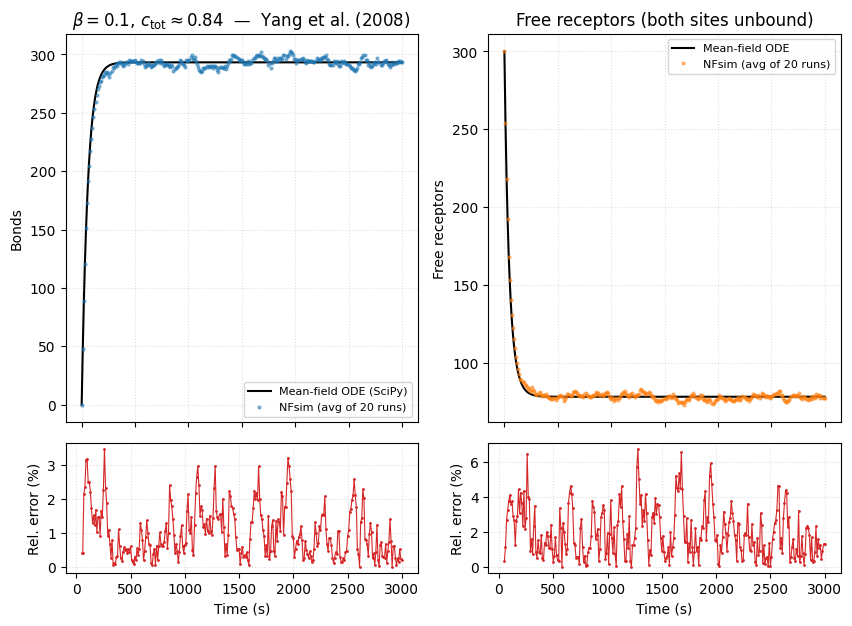

Saved verify_yang2008.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7),
                         height_ratios=[3, 1],
                         gridspec_kw={"hspace": 0.08})

# --- Top left: Bonds ---
ax = axes[0, 0]
ax.plot(bng_t, ode_bonds, "k-", lw=1.5,
        label="Mean-field ODE (SciPy)")
ax.plot(bng_t, bng_bonds, "o", color="tab:blue", ms=2, alpha=0.5,
        label=f"NFsim (avg of {N_RUNS} runs)")
ax.set_ylabel("Bonds")
ax.legend(fontsize=8, loc="lower right")
ax.set_title(r"$\beta = 0.1$, $c_\mathrm{tot} \approx 0.84$"
             "  —  Yang et al. (2008)")
ax.grid(True, ls=":", alpha=0.4)
ax.set_xticklabels([])

# --- Top right: Free receptors ---
ax = axes[0, 1]
ax.plot(bng_t, ode_free_R, "k-", lw=1.5,
        label="Mean-field ODE")
ax.plot(bng_t, bng_free_R, "o", color="tab:orange", ms=2, alpha=0.5,
        label=f"NFsim (avg of {N_RUNS} runs)")
ax.set_ylabel("Free receptors")
ax.legend(fontsize=8, loc="upper right")
ax.set_title("Free receptors (both sites unbound)")
ax.grid(True, ls=":", alpha=0.4)
ax.set_xticklabels([])

# --- Bottom left: Bond relative error ---
ax = axes[1, 0]
mask_plot = bng_t >= 50  # skip very early transient
rel_err_b = (np.abs(bng_bonds - ode_bonds)
             / np.clip(ode_bonds, 1, None) * 100)
ax.plot(bng_t[mask_plot], rel_err_b[mask_plot], ".-",
        color="tab:red", ms=2, lw=0.8)
ax.set_ylabel("Rel. error (%)")
ax.set_xlabel("Time (s)")
ax.grid(True, ls=":", alpha=0.4)

# --- Bottom right: Free receptor relative error ---
ax = axes[1, 1]
rel_err_r = (np.abs(bng_free_R - ode_free_R)
             / np.clip(ode_free_R, 1, None) * 100)
ax.plot(bng_t[mask_plot], rel_err_r[mask_plot], ".-",
        color="tab:red", ms=2, lw=0.8)
ax.set_ylabel("Rel. error (%)")
ax.set_xlabel("Time (s)")
ax.grid(True, ls=":", alpha=0.4)

fig.tight_layout()
plt.savefig("verify_yang2008.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved verify_yang2008.png")